# 11. Qwen2.5-VL 멀티이미지 · 멀티턴 대화

## 학습 목표

이전 Notebook에서는 이미지 한 장과 한국어 질문을 Qwen2.5-VL에 전달했다.

이번에는 두 가지 기능으로 확장한다.

```text
멀티이미지
Image A + Image B + Question
          ↓
       Qwen2.5-VL
          ↓
공통점 / 차이점 / 비교 분석
```

그리고 이전 대화를 유지하는 멀티턴 구조를 구현한다.

```text
Image
 ↓
User Question 1
 ↓
Assistant Answer 1
 ↓
User Question 2
 ↓
Assistant Answer 2
 ↓
User Question 3
 ↓
Assistant Answer 3
```

핵심 학습 내용은 다음과 같다.

- 여러 이미지를 하나의 Message에 넣는 방법
- `add_vision_id=True`
- 이미지 A/B 비교
- 공통점과 차이점 분석
- 다중 이미지 기반 질의응답
- Chat History
- User/Assistant Message 누적
- 멀티턴 한국어 VQA
- 생성 Token 분리
- 대화 초기화
- 사람 평가와 오류 분석

# 1. 단일 이미지에서 멀티이미지로

단일 이미지 입력은 다음 구조였다.

```text
User
├── Image
└── Text Question
```

멀티이미지는 하나의 User Message 안에 여러 개의 Image Content를 배치한다.

```text
User
├── Image A
├── Image B
└── "두 이미지를 비교해줘."
```

모델은 두 이미지와 질문을 함께 입력받아 비교 응답을 생성할 수 있다.

# 2. 멀티턴 대화란 무엇인가

멀티턴 대화에서는 현재 질문만 모델에 전달하지 않는다.

이전 대화 내용을 함께 전달한다.

```text
[
    User Message 1,
    Assistant Message 1,
    User Message 2,
    Assistant Message 2,
    User Message 3
]
```

따라서 다음과 같은 대화가 가능하다.

```text
사용자:
이 이미지를 설명해줘.

모델:
강아지가 보입니다.

사용자:
그 동물의 색은?

모델:
갈색 계열로 보입니다.

사용자:
배경은 어떻게 보여?

모델:
야외 배경으로 보입니다.
```

두 번째 질문의 `"그 동물"`은 이전 대화 문맥을 이용해야 이해할 수 있다.

# 3. 라이브러리 불러오기

In [2]:
# ---------------------------------------------------------
# Python Garbage Collection을 사용하기 위해 gc를 불러온다.
# ---------------------------------------------------------
import gc

# ---------------------------------------------------------
# PyTorch를 불러온다.
# ---------------------------------------------------------
import torch

# ---------------------------------------------------------
# 실습용 이미지를 사용하기 위해 CIFAR10을 불러온다.
# ---------------------------------------------------------
from torchvision.datasets import CIFAR10

# ---------------------------------------------------------
# Qwen2.5-VL의 멀티모달 입력 전처리를 위해
# AutoProcessor를 불러온다.
# ---------------------------------------------------------
from transformers import AutoProcessor

# ---------------------------------------------------------
# Qwen2.5-VL 생성 모델 클래스를 불러온다.
# ---------------------------------------------------------
from transformers import Qwen2_5_VLForConditionalGeneration

# ---------------------------------------------------------
# 이미지를 화면에 출력하기 위해 matplotlib을 불러온다.
# ---------------------------------------------------------
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 현재 PyTorch 버전을 출력한다.
# ---------------------------------------------------------
print(
    "PyTorch:",
    torch.__version__
)

c:\sk-encoa\llm-workspace\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.14.1+cpu


# 4. Device 설정

In [3]:
# ---------------------------------------------------------
# NVIDIA CUDA GPU를 사용할 수 있으면 CUDA를 선택한다.
# ---------------------------------------------------------
if torch.cuda.is_available():
    device = torch.device(
        "cuda"
    )

# ---------------------------------------------------------
# CUDA가 없고 Apple Silicon MPS가 사용 가능하면 MPS를 선택한다.
# ---------------------------------------------------------
elif (
    hasattr(torch.backends, "mps")   and  torch.backends.mps.is_available()):
    device = torch.device("mps")

# ---------------------------------------------------------
# GPU 가속을 사용할 수 없으면 CPU를 선택한다.
# ---------------------------------------------------------
else:
    device = torch.device("cpu")

# ---------------------------------------------------------
# 선택된 Device를 출력한다.
# ---------------------------------------------------------
print("Device:", device)

Device: cpu


# 5. 모델과 Processor 로드

이번 실습에서도 `Qwen/Qwen2.5-VL-3B-Instruct`를 사용한다.

CUDA에서는 `bfloat16`, 그 외 환경에서는 `float32`를 사용한다.

In [ ]:
# ---------------------------------------------------------
# 사용할 Qwen2.5-VL 모델 이름을 지정한다.
# ---------------------------------------------------------
MODEL_NAME = ("Qwen/Qwen2.5-VL-3B-Instruct")

# ---------------------------------------------------------
# CUDA 환경이면 bfloat16을 사용한다.
# ---------------------------------------------------------
if device.type == "cuda":
    model_dtype = torch.bfloat16

# ---------------------------------------------------------
# CUDA가 아니면 호환성을 우선하여 float32를 사용한다.
# ---------------------------------------------------------
else:
    model_dtype = torch.float32

# ---------------------------------------------------------
# Qwen2.5-VL용 Processor를 불러온다.
# ---------------------------------------------------------
processor = (
    AutoProcessor.from_pretrained(MODEL_NAME)
)

# ---------------------------------------------------------
# 사전학습된 Qwen2.5-VL 모델을 불러온다.
# ---------------------------------------------------------
model = (Qwen2_5_VLForConditionalGeneration.from_pretrained(MODEL_NAME,torch_dtype=model_dtype,low_cpu_mem_usage=True))

# ---------------------------------------------------------
# 모델을 선택한 Device로 이동한다.
# ---------------------------------------------------------
model = model.to(device)

# ---------------------------------------------------------
# 모델을 추론 모드로 변경한다.
# ---------------------------------------------------------
model.eval()

# ---------------------------------------------------------
# 모델이 올라간 실제 Device를 출력한다.
# ---------------------------------------------------------
print("Model Device:", next(model.parameters()).device)

ValueError: Using a `device_map`, `tp_plan`, `torch.device` context manager or setting `torch.set_default_device(device)` requires `accelerate`. You can install it with `pip install accelerate`

# 6. 서로 다른 클래스의 이미지 2장 준비

멀티이미지 비교가 명확하도록 CIFAR10에서 `dog`와 `automobile` 이미지를 각각 한 장 찾는다.

In [4]:
# ---------------------------------------------------------
# CIFAR10 Test Dataset을 PIL Image 형태로 불러온다.
# ---------------------------------------------------------
dataset = CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=None
)

# ---------------------------------------------------------
# CIFAR10 클래스 이름을 가져온다.
# ---------------------------------------------------------
class_names = dataset.classes

# ---------------------------------------------------------
# 첫 번째 비교 대상 클래스 이름을 지정한다.
# ---------------------------------------------------------
TARGET_CLASS_A = (
    "dog"
)

# ---------------------------------------------------------
# 두 번째 비교 대상 클래스 이름을 지정한다.
# ---------------------------------------------------------
TARGET_CLASS_B = ( "automobile")

# ---------------------------------------------------------
# 첫 번째 클래스의 정수 Label을 찾는다.
# ---------------------------------------------------------
target_label_a = class_names.index(TARGET_CLASS_A)

# ---------------------------------------------------------
# 두 번째 클래스의 정수 Label을 찾는다.
# ---------------------------------------------------------
target_label_b = class_names.index(TARGET_CLASS_B)

# ---------------------------------------------------------
# 첫 번째 이미지 변수를 초기화한다.
# ---------------------------------------------------------
image_a = None

# ---------------------------------------------------------
# 두 번째 이미지 변수를 초기화한다.
# ---------------------------------------------------------
image_b = None

# ---------------------------------------------------------
# CIFAR10 Test Dataset을 순서대로 탐색한다.
# ---------------------------------------------------------
for current_image, current_label in dataset:

    # -----------------------------------------------------
    # 아직 첫 번째 이미지를 찾지 않았고 현재 Label이
    # 첫 번째 목표 클래스이면 이미지를 저장한다.
    # -----------------------------------------------------
    if (image_a is None and current_label == target_label_a ):
        image_a = current_image

    # -----------------------------------------------------
    # 아직 두 번째 이미지를 찾지 않았고 현재 Label이
    # 두 번째 목표 클래스이면 이미지를 저장한다.
    # -----------------------------------------------------
    if (image_b is None and current_label == target_label_b):
        image_b = current_image

    # -----------------------------------------------------
    # 두 이미지를 모두 찾았으면 Dataset 탐색을 종료한다.
    # -----------------------------------------------------
    if (image_a is not None  and image_b is not None):
        break

# ---------------------------------------------------------
# 두 이미지가 정상적으로 준비되었는지 확인한다.
# ---------------------------------------------------------
assert image_a is not None
assert image_b is not None

# ---------------------------------------------------------
# 준비된 두 클래스 이름을 출력한다.
# ---------------------------------------------------------
print("Image A:", TARGET_CLASS_A)
print("Image B:",TARGET_CLASS_B)

Image A: dog
Image B: automobile


# 7. 두 이미지 시각화

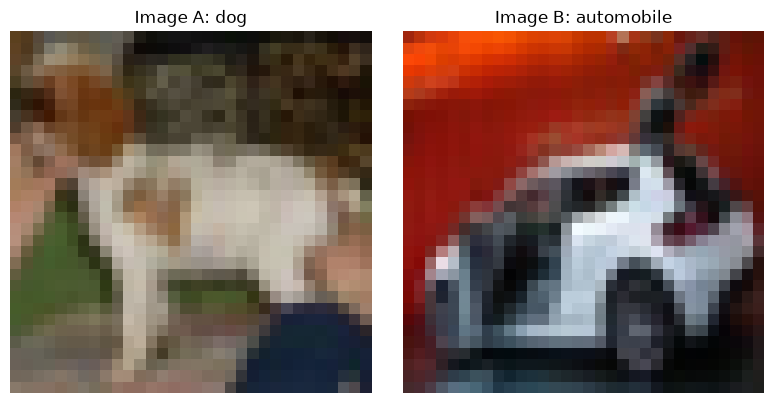

In [5]:
# ---------------------------------------------------------
# 두 이미지를 나란히 표시할 Figure를 만든다.
# ---------------------------------------------------------
plt.figure(
    figsize=(8, 4)
)

# ---------------------------------------------------------
# 첫 번째 subplot을 선택한다.
# ---------------------------------------------------------
plt.subplot(
    1,
    2,
    1
)

# ---------------------------------------------------------
# 첫 번째 이미지를 표시한다.
# ---------------------------------------------------------
plt.imshow(
    image_a
)

# ---------------------------------------------------------
# 첫 번째 이미지의 실제 클래스를 제목으로 표시한다.
# ---------------------------------------------------------
plt.title(
    f"Image A: {TARGET_CLASS_A}"
)

# ---------------------------------------------------------
# 첫 번째 이미지의 축 눈금을 제거한다.
# ---------------------------------------------------------
plt.axis("off")

# ---------------------------------------------------------
# 두 번째 subplot을 선택한다.
# ---------------------------------------------------------
plt.subplot( 1, 2, 2)

# ---------------------------------------------------------
# 두 번째 이미지를 표시한다.
# ---------------------------------------------------------
plt.imshow( image_b)

# ---------------------------------------------------------
# 두 번째 이미지의 실제 클래스를 제목으로 표시한다.
# ---------------------------------------------------------
plt.title(f"Image B: {TARGET_CLASS_B}")

# ---------------------------------------------------------
# 두 번째 이미지의 축 눈금을 제거한다.
# ---------------------------------------------------------
plt.axis("off")

# ---------------------------------------------------------
# subplot 간격을 자동 조정한다.
# ---------------------------------------------------------
plt.tight_layout()

# ---------------------------------------------------------
# 두 이미지를 화면에 출력한다.
# ---------------------------------------------------------
plt.show()

# 8. 멀티이미지 Message 만들기

한 User Message의 `content` 안에 이미지 2장과 질문을 순서대로 넣는다.

```text
content
├── image A
├── image B
└── text
```

In [6]:
# ---------------------------------------------------------
# 두 이미지를 비교하도록 요청하는 한국어 질문을 정의한다.
# ---------------------------------------------------------
compare_question = (
    "첫 번째 이미지와 두 번째 이미지를 비교해줘. "
    "각 이미지의 주요 객체가 무엇인지 말하고 "
    "공통점과 차이점을 한국어로 설명해줘."
)

# ---------------------------------------------------------
# 두 이미지와 한국어 질문을 하나의 User Message로 구성한다.
# ---------------------------------------------------------
multi_image_messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": image_a
            },
            {
                "type": "image",
                "image": image_b
            },
            {
                "type": "text",
                "text": compare_question
            }
        ]
    }
]

# ---------------------------------------------------------
# Message의 개수를 출력한다.
# ---------------------------------------------------------
print( "Message Count:", len( multi_image_messages ))

# ---------------------------------------------------------
# 첫 번째 User Message의 Content 개수를 출력한다.
# ---------------------------------------------------------
print("Content Count:", len(multi_image_messages[ 0 ][ "content" ]))

Message Count: 1
Content Count: 3


# 9. add_vision_id=True

여러 이미지를 사용할 때는 각 시각 입력을 구분하기 쉬운 표지가 유용하다.

`add_vision_id=True`를 사용하면 Chat Template에서 이미지 참조를 구분하는 데 도움이 된다.

수업에서는 이 옵션을 사용하여 모델이 여러 시각 입력을 어떻게 구분하도록 Prompt가 구성되는지 확인한다.

In [7]:
# ---------------------------------------------------------
# 여러 이미지에 Vision ID를 추가한 Chat Template 문자열을 만든다.
# 이 셀은 Template 구조를 관찰하기 위한 용도이다.
# ---------------------------------------------------------
template_text = processor.apply_chat_template(
    multi_image_messages,
    tokenize=False,
    add_generation_prompt=True,
    add_vision_id=True
)

# ---------------------------------------------------------
# 생성된 Chat Template 문자열을 출력한다.
# ---------------------------------------------------------
print(
    template_text
)

<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
Picture 1: <|vision_start|><|image_pad|><|vision_end|>Picture 2: <|vision_start|><|image_pad|><|vision_end|>첫 번째 이미지와 두 번째 이미지를 비교해줘. 각 이미지의 주요 객체가 무엇인지 말하고 공통점과 차이점을 한국어로 설명해줘.<|im_end|>
<|im_start|>assistant



# 10. 멀티이미지 입력 Tensor 생성

`tokenize=True`, `return_dict=True`, `return_tensors="pt"`를 사용하면 텍스트 Token과 이미지 입력이 함께 포함된 모델 입력을 만들 수 있다.

In [8]:
# ---------------------------------------------------------
# 두 이미지와 질문을 모델 입력 Tensor로 변환한다.
# ---------------------------------------------------------
multi_inputs = processor.apply_chat_template(
    multi_image_messages,
    tokenize=True,
    add_generation_prompt=True,
    add_vision_id=True,
    return_dict=True,
    return_tensors="pt"
)

# ---------------------------------------------------------
# Processor가 생성한 입력 Key를 출력한다.
# ---------------------------------------------------------
print("Input Keys:", multi_inputs.keys())

# ---------------------------------------------------------
# 각 Tensor의 이름과 shape을 확인한다.
# ---------------------------------------------------------
for key, value in multi_inputs.items():

    # -----------------------------------------------------
    # 현재 값이 Tensor인 경우에만 shape을 출력한다.
    # -----------------------------------------------------
    if isinstance(value, torch.Tensor ):
        print( key, value.shape)

Input Keys: KeysView({'input_ids': tensor([[151644,   8948,    198,   2610,    525,    264,  10950,  17847,     13,
         151645,    198, 151644,    872,    198,  24669,    220,     16,     25,
            220, 151652, 151655, 151655, 151655, 151655, 151653,  24669,    220,
             17,     25,    220, 151652, 151655, 151655, 151655, 151655, 151653,
         136689,  84621,  83666,  90667,  21329,  80573, 129419,  84621,  83666,
          90667, 133120, 142350,  33883, 144131,     13, 126804,  90667,  21329,
          20401,  55673,  35711,  75232,  19969, 132779, 134039, 126254, 126204,
         125466, 125160, 126333,  53680, 129882,  12802, 138913, 130092,  31079,
          17380, 133828,  33883, 144131,     13, 151645,    198, 151644,  77091,
            198]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 

# 11. 멀티이미지 비교 응답 생성

In [9]:
# ---------------------------------------------------------
# 모든 멀티이미지 입력 Tensor를 모델 Device로 이동한다.
# ---------------------------------------------------------
multi_inputs = multi_inputs.to(device)

# ---------------------------------------------------------
# 각 Batch의 실제 입력 Token 길이를 저장한다.
# ---------------------------------------------------------
input_lengths = [len(input_ids)for input_ids in multi_inputs["input_ids"]]

# ---------------------------------------------------------
# 멀티이미지 비교는 추론이므로 Gradient 계산을 비활성화한다.
# ---------------------------------------------------------
with torch.inference_mode():

    # -----------------------------------------------------
    # 두 이미지와 질문을 기반으로 응답 Token을 생성한다.
    # -----------------------------------------------------
    generated_ids = model.generate(
        **multi_inputs,
        max_new_tokens=180,
        do_sample=False
    )

# ---------------------------------------------------------
# 각 Batch별로 입력 Prompt Token을 제외하고
# 새로 생성된 Token만 분리한다.
# ---------------------------------------------------------
trimmed_ids = [output_ids[input_length: ]
    for input_length, output_ids in zip(
        input_lengths,
        generated_ids
    )
]

# ---------------------------------------------------------
# 새로 생성된 Token만 자연어 문자열로 변환한다.
# ---------------------------------------------------------
compare_response = processor.batch_decode(
    trimmed_ids,
    skip_special_tokens=True,
    clean_up_tokenization_spaces=False
)[0]

# ---------------------------------------------------------
# 비교 질문을 출력한다.
# ---------------------------------------------------------
print( "질문:", compare_question)

# ---------------------------------------------------------
# 모델의 비교 응답을 출력한다.
# ---------------------------------------------------------
print("답변:",compare_response)

질문: 첫 번째 이미지와 두 번째 이미지를 비교해줘. 각 이미지의 주요 객체가 무엇인지 말하고 공통점과 차이점을 한국어로 설명해줘.
답변: 두 번째 이미지는 자동차 모델을 보여주고 있습니다. 이 모델은 다양한 색상과 디자인 요소를 가지고 있으며, 특히 블랙과 흰색이 주요 색상입니다. 이 모델은 일반적인 자동차 모델과 유사하지만, 구체적인 차량 모델을 나타내는 것보다는 일반적인 자동차의 외관을 표현하는 것 같습니다.

반면에, 첫 번째 이미지는 개의 모습을 보여주고 있습니다. 이 개는 흰색과 검은색의 털을 가지고 있으며, 귀와 눈이 잘 보입니다. 이 개는 일반적으로 사람과 함께 산책하거나 집에서 휴식하는 모습을 보여줍니다.

두 이미지의 주


# 12. 재사용 가능한 멀티이미지 함수

두 개 이상의 PIL Image와 질문을 받아 응답하는 함수로 일반화한다.

In [10]:
# ---------------------------------------------------------
# 여러 PIL Image와 질문을 받아 응답을 생성하는 함수를 정의한다.
# ---------------------------------------------------------
def ask_multiple_images(
    images,
    question,
    model,
    processor,
    device,
    max_new_tokens=180
):
    # -----------------------------------------------------
    # User Message의 Content를 저장할 리스트를 만든다.
    # -----------------------------------------------------
    content = []

    # -----------------------------------------------------
    # 전달받은 모든 PIL Image를 순서대로 Content에 추가한다.
    # -----------------------------------------------------
    for image in images:
        content.append(
            {
                "type": "image",
                "image": image
            }
        )

    # -----------------------------------------------------
    # 모든 이미지 다음에 자연어 질문을 추가한다.
    # -----------------------------------------------------
    content.append(
        {
            "type": "text",
            "text": question
        }
    )

    # -----------------------------------------------------
    # 완성된 Content를 하나의 User Message로 구성한다.
    # -----------------------------------------------------
    messages = [
        {
            "role": "user",
            "content": content
        }
    ]

    # -----------------------------------------------------
    # Multimodal Chat Template을 적용하고 모델 입력을 생성한다.
    # -----------------------------------------------------
    inputs = processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        add_vision_id=True,
        return_dict=True,
        return_tensors="pt"
    )

    # -----------------------------------------------------
    # 모델 입력을 모델과 같은 Device로 이동한다.
    # -----------------------------------------------------
    inputs = inputs.to(
        device
    )

    # -----------------------------------------------------
    # 각 Batch의 입력 Token 길이를 저장한다.
    # -----------------------------------------------------
    input_lengths = [
        len(
            input_ids
        )
        for input_ids in inputs[
            "input_ids"
        ]
    ]

    # -----------------------------------------------------
    # 응답 생성은 추론이므로 Gradient 계산을 비활성화한다.
    # -----------------------------------------------------
    with torch.inference_mode():

        # -------------------------------------------------
        # 여러 이미지와 질문을 기반으로 응답을 생성한다.
        # -------------------------------------------------
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False
        )

    # -----------------------------------------------------
    # 각 출력에서 입력 Prompt Token 부분을 제거한다.
    # -----------------------------------------------------
    response_ids = [
        generated[
            input_length:
        ]
        for input_length, generated in zip(
            input_lengths,
            output_ids
        )
    ]

    # -----------------------------------------------------
    # 새로 생성된 Token을 자연어 문자열로 변환한다.
    # -----------------------------------------------------
    answer = processor.batch_decode(
        response_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0]

    # -----------------------------------------------------
    # 최종 응답을 반환한다.
    # -----------------------------------------------------
    return answer

# 13. 공통점 질문

In [11]:
# ---------------------------------------------------------
# 두 이미지의 공통점을 묻는 질문을 정의한다.
# ---------------------------------------------------------
similarity_question = (
    "두 이미지의 공통점을 찾아서 "
    "한국어로 3가지 이내로 설명해줘."
)

# ---------------------------------------------------------
# 멀티이미지 함수를 이용하여 공통점을 분석한다.
# ---------------------------------------------------------
similarity_answer = ask_multiple_images(
    [
        image_a,
        image_b
    ],
    similarity_question,
    model,
    processor,
    device
)

# ---------------------------------------------------------
# 공통점 분석 결과를 출력한다.
# ---------------------------------------------------------
print(
    similarity_answer
)

KeyboardInterrupt: 

# 14. 차이점 질문

In [ ]:
# ---------------------------------------------------------
# 두 이미지의 차이점을 묻는 질문을 정의한다.
# ---------------------------------------------------------
difference_question = (
    "첫 번째 이미지와 두 번째 이미지의 차이점을 "
    "객체 종류, 외형, 장면 관점에서 설명해줘."
)

# ---------------------------------------------------------
# 두 이미지의 차이점을 모델에 질문한다.
# ---------------------------------------------------------
difference_answer = ask_multiple_images(
    [
        image_a,
        image_b
    ],
    difference_question,
    model,
    processor,
    device
)

# ---------------------------------------------------------
# 차이점 분석 결과를 출력한다.
# ---------------------------------------------------------
print(
    difference_answer
)

# 15. 구조화된 멀티이미지 분석

자유로운 문장 대신 원하는 형식을 Prompt에 명시할 수 있다.

In [ ]:
# ---------------------------------------------------------
# 구조화된 비교 결과를 요구하는 Prompt를 정의한다.
# ---------------------------------------------------------
structured_question = (
    "두 이미지를 분석해서 다음 형식으로 답해줘.\n"
    "첫 번째 이미지 객체: ...\n"
    "두 번째 이미지 객체: ...\n"
    "공통점: ...\n"
    "차이점: ...\n"
    "한 줄 결론: ..."
)

# ---------------------------------------------------------
# 구조화된 멀티이미지 분석을 실행한다.
# ---------------------------------------------------------
structured_answer = ask_multiple_images(
    [
        image_a,
        image_b
    ],
    structured_question,
    model,
    processor,
    device,
    max_new_tokens=200
)

# ---------------------------------------------------------
# 구조화된 분석 결과를 출력한다.
# ---------------------------------------------------------
print(
    structured_answer
)

# 16. 멀티턴 대화의 핵심: History

이제 이미지 한 장을 기준으로 여러 질문을 연속해서 수행한다.

핵심은 이전 Assistant 답변을 History에 추가하는 것이다.

```text
messages

User(Image + Q1)
Assistant(A1)
User(Q2)
Assistant(A2)
User(Q3)
```

새 질문을 할 때마다 이 전체 History를 다시 Chat Template에 적용한다.

# 17. 멀티턴 History 초기화

첫 번째 Turn에서는 이미지를 함께 전달한다.

In [ ]:
# ---------------------------------------------------------
# 멀티턴 대화에서 사용할 첫 번째 이미지를 선택한다.
# ---------------------------------------------------------
conversation_image = image_a

# ---------------------------------------------------------
# 첫 번째 질문을 정의한다.
# ---------------------------------------------------------
first_question = (
    "이 이미지의 주요 객체가 무엇인지 한국어로 설명해줘."
)

# ---------------------------------------------------------
# 첫 번째 User Message로 대화 History를 초기화한다.
# ---------------------------------------------------------
conversation = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": conversation_image
            },
            {
                "type": "text",
                "text": first_question
            }
        ]
    }
]

# ---------------------------------------------------------
# 현재 대화 Message 개수를 출력한다.
# ---------------------------------------------------------
print(
    "Conversation Messages:",
    len(
        conversation
    )
)

# 18. 현재 History로 응답을 생성하는 함수

이 함수는 전달된 전체 `conversation`을 모델에 넣고 Assistant 응답을 반환한다.

In [ ]:
# ---------------------------------------------------------
# 현재 전체 대화 History를 이용하여 Assistant 응답을
# 생성하는 함수를 정의한다.
# ---------------------------------------------------------
def generate_from_history(
    conversation,
    model,
    processor,
    device,
    max_new_tokens=120
):
    # -----------------------------------------------------
    # 전체 대화 History에 Chat Template을 적용한다.
    # -----------------------------------------------------
    inputs = processor.apply_chat_template(
        conversation,
        tokenize=True,
        add_generation_prompt=True,
        add_vision_id=True,
        return_dict=True,
        return_tensors="pt"
    )

    # -----------------------------------------------------
    # 모든 입력 Tensor를 모델 Device로 이동한다.
    # -----------------------------------------------------
    inputs = inputs.to(
        device
    )

    # -----------------------------------------------------
    # 각 Batch의 입력 Token 길이를 저장한다.
    # -----------------------------------------------------
    input_lengths = [
        len(
            input_ids
        )
        for input_ids in inputs[
            "input_ids"
        ]
    ]

    # -----------------------------------------------------
    # 대화 응답 생성은 추론이므로 Gradient 계산을 비활성화한다.
    # -----------------------------------------------------
    with torch.inference_mode():

        # -------------------------------------------------
        # 현재 전체 대화를 조건으로 Assistant 응답을 생성한다.
        # -------------------------------------------------
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False
        )

    # -----------------------------------------------------
    # 각 출력에서 입력 History Token을 제거한다.
    # -----------------------------------------------------
    response_ids = [
        generated[
            input_length:
        ]
        for input_length, generated in zip(
            input_lengths,
            output_ids
        )
    ]

    # -----------------------------------------------------
    # 새로 생성된 Assistant Token만 문자열로 변환한다.
    # -----------------------------------------------------
    answer = processor.batch_decode(
        response_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0]

    # -----------------------------------------------------
    # Assistant 응답을 반환한다.
    # -----------------------------------------------------
    return answer

# 19. 첫 번째 Turn 실행

In [ ]:
# ---------------------------------------------------------
# 첫 번째 User Message에 대한 Assistant 응답을 생성한다.
# ---------------------------------------------------------
first_answer = generate_from_history(
    conversation,
    model,
    processor,
    device
)

# ---------------------------------------------------------
# 생성된 Assistant 응답을 대화 History에 추가한다.
# ---------------------------------------------------------
conversation.append(
    {
        "role": "assistant",
        "content": first_answer
    }
)

# ---------------------------------------------------------
# 첫 번째 질문을 출력한다.
# ---------------------------------------------------------
print(
    "User:",
    first_question
)

# ---------------------------------------------------------
# 첫 번째 답변을 출력한다.
# ---------------------------------------------------------
print(
    "Assistant:",
    first_answer
)

# 20. 두 번째 Turn: 대명사와 이전 문맥

두 번째 질문에는 이미지를 다시 직접 설명하지 않는다.

```text
"그 객체의 외형적 특징은?"
```

여기서 `"그 객체"`를 이해하려면 첫 번째 질문과 답변의 문맥이 필요하다.

In [ ]:
# ---------------------------------------------------------
# 이전 대화 문맥을 필요로 하는 두 번째 질문을 정의한다.
# ---------------------------------------------------------
second_question = (
    "그 객체의 외형적 특징은 어떻게 보여?"
)

# ---------------------------------------------------------
# 두 번째 User Message를 기존 History에 추가한다.
# ---------------------------------------------------------
conversation.append(
    {
        "role": "user",
        "content": [
            {
                "type": "text",
                "text": second_question
            }
        ]
    }
)

# ---------------------------------------------------------
# 전체 History를 이용하여 두 번째 답변을 생성한다.
# ---------------------------------------------------------
second_answer = generate_from_history(
    conversation,
    model,
    processor,
    device
)

# ---------------------------------------------------------
# 두 번째 Assistant 응답을 History에 추가한다.
# ---------------------------------------------------------
conversation.append(
    {
        "role": "assistant",
        "content": second_answer
    }
)

# ---------------------------------------------------------
# 두 번째 질문을 출력한다.
# ---------------------------------------------------------
print(
    "User:",
    second_question
)

# ---------------------------------------------------------
# 두 번째 답변을 출력한다.
# ---------------------------------------------------------
print(
    "Assistant:",
    second_answer
)

# 21. 세 번째 Turn: 추가 문맥 질문

In [ ]:
# ---------------------------------------------------------
# 이미지의 배경을 묻는 세 번째 질문을 정의한다.
# ---------------------------------------------------------
third_question = (
    "그 이미지의 배경이나 주변 환경은 어떻게 보여?"
)

# ---------------------------------------------------------
# 세 번째 User Message를 History에 추가한다.
# ---------------------------------------------------------
conversation.append(
    {
        "role": "user",
        "content": [
            {
                "type": "text",
                "text": third_question
            }
        ]
    }
)

# ---------------------------------------------------------
# 누적된 전체 History를 이용하여 세 번째 답변을 생성한다.
# ---------------------------------------------------------
third_answer = generate_from_history(
    conversation,
    model,
    processor,
    device
)

# ---------------------------------------------------------
# 세 번째 Assistant 응답을 History에 추가한다.
# ---------------------------------------------------------
conversation.append(
    {
        "role": "assistant",
        "content": third_answer
    }
)

# ---------------------------------------------------------
# 세 번째 질문을 출력한다.
# ---------------------------------------------------------
print(
    "User:",
    third_question
)

# ---------------------------------------------------------
# 세 번째 답변을 출력한다.
# ---------------------------------------------------------
print(
    "Assistant:",
    third_answer
)

# 22. 네 번째 Turn: 이전 답변 요약

멀티턴의 장점을 확인하기 위해 앞 대화 내용을 종합하도록 요청한다.

In [ ]:
# ---------------------------------------------------------
# 지금까지의 내용을 요약하도록 네 번째 질문을 정의한다.
# ---------------------------------------------------------
fourth_question = (
    "지금까지 이야기한 내용을 바탕으로 "
    "이 이미지를 한 문장으로 요약해줘."
)

# ---------------------------------------------------------
# 네 번째 User Message를 History에 추가한다.
# ---------------------------------------------------------
conversation.append(
    {
        "role": "user",
        "content": [
            {
                "type": "text",
                "text": fourth_question
            }
        ]
    }
)

# ---------------------------------------------------------
# 전체 대화 문맥을 이용하여 네 번째 답변을 생성한다.
# ---------------------------------------------------------
fourth_answer = generate_from_history(
    conversation,
    model,
    processor,
    device
)

# ---------------------------------------------------------
# 네 번째 Assistant 응답을 History에 추가한다.
# ---------------------------------------------------------
conversation.append(
    {
        "role": "assistant",
        "content": fourth_answer
    }
)

# ---------------------------------------------------------
# 네 번째 질문을 출력한다.
# ---------------------------------------------------------
print(
    "User:",
    fourth_question
)

# ---------------------------------------------------------
# 네 번째 답변을 출력한다.
# ---------------------------------------------------------
print(
    "Assistant:",
    fourth_answer
)

# 23. 전체 대화 History 확인

In [ ]:
# ---------------------------------------------------------
# 현재까지 누적된 모든 Message를 순서대로 확인한다.
# ---------------------------------------------------------
for index, message in enumerate(
    conversation,
    start=1
):
    # -----------------------------------------------------
    # 현재 Message의 Role을 가져온다.
    # -----------------------------------------------------
    role = message[
        "role"
    ]

    # -----------------------------------------------------
    # Message 번호와 Role을 출력한다.
    # -----------------------------------------------------
    print(
        f"[{index}] {role}"
    )

    # -----------------------------------------------------
    # 현재 Content가 문자열이면 그대로 출력한다.
    # -----------------------------------------------------
    if isinstance(
        message[
            "content"
        ],
        str
    ):
        print(
            message[
                "content"
            ]
        )

    # -----------------------------------------------------
    # 현재 Content가 List이면 각 Content Block을 확인한다.
    # -----------------------------------------------------
    else:
        for content_item in message[
            "content"
        ]:

            # -------------------------------------------------
            # Text Content인 경우 실제 Text를 출력한다.
            # -------------------------------------------------
            if content_item[
                "type"
            ] == "text":
                print(
                    content_item[
                        "text"
                    ]
                )

            # -------------------------------------------------
            # Image Content인 경우 이미지가 포함되었음을 출력한다.
            # -------------------------------------------------
            elif content_item[
                "type"
            ] == "image":
                print(
                    "<IMAGE>"
                )

    # -----------------------------------------------------
    # Message 사이에 구분선을 출력한다.
    # -----------------------------------------------------
    print(
        "-" * 70
    )

# 24. 멀티턴에서 중요한 점

멀티턴은 모델 내부에 자동으로 영구 기억이 생기는 방식이 아니다.

코드에서 이전 대화를 `conversation` 리스트에 계속 보관하고 다음 추론 시 다시 전달하고 있다.

```text
conversation
     ↓
apply_chat_template()
     ↓
전체 History를 다시 모델 입력으로 구성
     ↓
다음 Response 생성
```

따라서 History가 길어질수록 입력 Token 수도 증가할 수 있다.

# 25. 재사용 가능한 멀티턴 Chat 클래스

수업에서 사용하기 쉽도록 대화 상태를 관리하는 간단한 클래스를 구현한다.

In [ ]:
# ---------------------------------------------------------
# Qwen2.5-VL 멀티턴 대화 상태를 관리하는 클래스를 정의한다.
# ---------------------------------------------------------
class MultimodalChat:

    # -----------------------------------------------------
    # Model, Processor, Device를 받아 객체를 초기화한다.
    # -----------------------------------------------------
    def __init__(
        self,
        model,
        processor,
        device
    ):
        # -------------------------------------------------
        # 사용할 Model을 객체 속성에 저장한다.
        # -------------------------------------------------
        self.model = model

        # -------------------------------------------------
        # 사용할 Processor를 객체 속성에 저장한다.
        # -------------------------------------------------
        self.processor = processor

        # -------------------------------------------------
        # 사용할 Device를 객체 속성에 저장한다.
        # -------------------------------------------------
        self.device = device

        # -------------------------------------------------
        # 대화 History를 빈 리스트로 초기화한다.
        # -------------------------------------------------
        self.messages = []

    # -----------------------------------------------------
    # 새 대화를 시작하기 위해 History를 초기화하는
    # 메서드를 정의한다.
    # -----------------------------------------------------
    def reset(
        self
    ):
        # -------------------------------------------------
        # 저장된 모든 Message를 제거한다.
        # -------------------------------------------------
        self.messages = []

    # -----------------------------------------------------
    # 첫 Turn에서 Image와 Question을 함께 전달하는
    # 메서드를 정의한다.
    # -----------------------------------------------------
    def ask_with_image(
        self,
        image,
        question,
        max_new_tokens=120
    ):
        # -------------------------------------------------
        # Image와 Question을 User Message로 추가한다.
        # -------------------------------------------------
        self.messages.append(
            {
                "role": "user",
                "content": [
                    {
                        "type": "image",
                        "image": image
                    },
                    {
                        "type": "text",
                        "text": question
                    }
                ]
            }
        )

        # -------------------------------------------------
        # 현재 전체 History로 Assistant 응답을 생성한다.
        # -------------------------------------------------
        answer = generate_from_history(
            self.messages,
            self.model,
            self.processor,
            self.device,
            max_new_tokens=max_new_tokens
        )

        # -------------------------------------------------
        # 생성된 Assistant 응답을 History에 추가한다.
        # -------------------------------------------------
        self.messages.append(
            {
                "role": "assistant",
                "content": answer
            }
        )

        # -------------------------------------------------
        # 최종 Assistant 응답을 반환한다.
        # -------------------------------------------------
        return answer

    # -----------------------------------------------------
    # 두 번째 Turn 이후 Text Question만 추가하는
    # 메서드를 정의한다.
    # -----------------------------------------------------
    def ask(
        self,
        question,
        max_new_tokens=120
    ):
        # -------------------------------------------------
        # 새로운 Text Question을 User Message로 추가한다.
        # -------------------------------------------------
        self.messages.append(
            {
                "role": "user",
                "content": [
                    {
                        "type": "text",
                        "text": question
                    }
                ]
            }
        )

        # -------------------------------------------------
        # 전체 대화 History를 이용하여 응답을 생성한다.
        # -------------------------------------------------
        answer = generate_from_history(
            self.messages,
            self.model,
            self.processor,
            self.device,
            max_new_tokens=max_new_tokens
        )

        # -------------------------------------------------
        # 생성된 Assistant 응답을 History에 추가한다.
        # -------------------------------------------------
        self.messages.append(
            {
                "role": "assistant",
                "content": answer
            }
        )

        # -------------------------------------------------
        # 최종 Assistant 응답을 반환한다.
        # -------------------------------------------------
        return answer

# 26. MultimodalChat 사용 예제

In [ ]:
# ---------------------------------------------------------
# 멀티턴 Chat 객체를 생성한다.
# ---------------------------------------------------------
chat = MultimodalChat(
    model,
    processor,
    device
)

# ---------------------------------------------------------
# 첫 Turn에서 Image와 Question을 함께 전달한다.
# ---------------------------------------------------------
answer_1 = chat.ask_with_image(
    image_b,
    "이 이미지의 주요 객체를 설명해줘."
)

# ---------------------------------------------------------
# 첫 번째 답변을 출력한다.
# ---------------------------------------------------------
print(
    "A1:",
    answer_1
)

# ---------------------------------------------------------
# 이전 문맥을 사용하는 후속 질문을 전달한다.
# ---------------------------------------------------------
answer_2 = chat.ask(
    "그 객체는 어떤 용도로 사용되는 물체야?"
)

# ---------------------------------------------------------
# 두 번째 답변을 출력한다.
# ---------------------------------------------------------
print(
    "A2:",
    answer_2
)

# ---------------------------------------------------------
# 다시 이전 문맥을 사용하는 질문을 전달한다.
# ---------------------------------------------------------
answer_3 = chat.ask(
    "지금까지의 답변을 두 문장으로 정리해줘."
)

# ---------------------------------------------------------
# 세 번째 답변을 출력한다.
# ---------------------------------------------------------
print(
    "A3:",
    answer_3
)

# 27. 대화 초기화

새로운 이미지에 대해 대화를 시작하려면 기존 History를 제거해야 한다.

In [ ]:
# ---------------------------------------------------------
# 현재 Chat History에 저장된 Message 개수를 출력한다.
# ---------------------------------------------------------
print(
    "Before Reset:",
    len(
        chat.messages
    )
)

# ---------------------------------------------------------
# 기존 대화 History를 초기화한다.
# ---------------------------------------------------------
chat.reset()

# ---------------------------------------------------------
# 초기화 후 Message 개수를 출력한다.
# ---------------------------------------------------------
print(
    "After Reset:",
    len(
        chat.messages
    )
)

# 28. 멀티이미지와 멀티턴의 차이

| 구분 | 멀티이미지 | 멀티턴 |
|---|---|---|
| 핵심 | 한 요청에 여러 이미지 | 여러 번 이어지는 대화 |
| 이미지 수 | 2장 이상 가능 | 한 장 또는 여러 장 가능 |
| 질문 | 한 번의 비교 질문 가능 | 후속 질문 가능 |
| History | 필수 아님 | 중요 |
| 주요 활용 | 비교, 관계 분석 | 대화형 이미지 분석 |

두 개념을 함께 사용할 수도 있다.

```text
Image A + Image B
        ↓
"두 이미지를 비교해줘."
        ↓
Assistant Answer
        ↓
"첫 번째 이미지에 대해서만 더 자세히 설명해줘."
        ↓
Assistant Answer
        ↓
"두 번째 이미지와 가장 큰 차이는?"
```

# 29. 멀티이미지 평가 기준

여러 이미지를 비교할 때는 다음 항목을 확인한다.

```text
1. Image A 객체를 정확히 인식했는가?
2. Image B 객체를 정확히 인식했는가?
3. 두 이미지를 서로 혼동하지 않았는가?
4. 공통점을 이미지에 근거하여 설명했는가?
5. 차이점을 이미지에 근거하여 설명했는가?
6. 존재하지 않는 내용을 생성하지 않았는가?
```

특히 여러 이미지를 입력하면 어느 이미지에 대한 설명인지 혼동하는 오류가 발생할 수 있으므로 이미지 참조 관계를 확인해야 한다.

# 30. 멀티턴 평가 기준

멀티턴에서는 단일 답변 정확도 외에 문맥 유지 능력을 평가한다.

```text
Context Consistency
→ 이전 답변과 모순되지 않는가?

Reference Resolution
→ "그 객체", "첫 번째 이미지" 같은 표현을 이해하는가?

Image Grounding
→ 답변이 실제 이미지에 근거하는가?

Conversation Continuity
→ 이전 질문을 고려하여 답하는가?

Hallucination
→ 대화가 길어지면서 없는 정보를 추가하지 않는가?
```

# 31. 확인 문제

1. 멀티이미지 입력은 하나의 User Message에서 어떻게 구성하는가?
2. 이미지 2장을 비교할 때 Text Content는 어디에 추가하는가?
3. `add_vision_id=True`를 사용하는 이유는 무엇인가?
4. 여러 이미지 입력에서도 `apply_chat_template()`을 사용할 수 있는가?
5. 멀티턴 대화에서 History가 필요한 이유는 무엇인가?
6. 두 번째 질문에서 이미지를 다시 넣지 않아도 이전 이미지를 참조할 수 있는 이유는 무엇인가?
7. 모델 자체에 영구적으로 대화가 저장되는 것인가?
8. 새 질문을 할 때 이전 대화를 다시 모델 입력으로 전달하는가?
9. `role="assistant"` Message를 History에 추가하는 이유는 무엇인가?
10. `conversation`이 길어지면 어떤 비용이 증가할 수 있는가?
11. `reset()`은 어떤 역할을 하는가?
12. 멀티이미지와 멀티턴을 동시에 사용할 수 있는가?
13. 여러 이미지를 비교할 때 발생할 수 있는 대표 오류는 무엇인가?
14. 멀티턴에서 Reference Resolution은 무엇을 평가하는가?
15. 생성 결과에서 입력 Token을 제거하는 이유는 무엇인가?

# 32. 확인 문제 정답

1. `content` 리스트 안에 여러 개의 `type="image"` 항목을 순서대로 추가한다.
2. 여러 Image Content 다음에 `type="text"` Content로 질문을 추가할 수 있다.
3. 여러 시각 입력을 구분하기 쉬운 이미지 참조 표지를 Chat Template에 추가하기 위해 사용한다.
4. 사용할 수 있다.
5. 이전 질문과 답변을 참고하여 후속 질문의 문맥을 이해해야 하기 때문이다.
6. 이전 Image Message가 전체 History에 남아 있고 다음 추론에서도 함께 전달되기 때문이다.
7. 아니다. 이 실습에서는 Python 코드의 `conversation` 또는 `messages` 리스트가 History를 보관한다.
8. 그렇다. 누적된 History를 다시 Chat Template에 적용하여 입력한다.
9. 이전에 모델이 무엇이라고 답했는지 다음 Turn의 문맥에 포함하기 위해서이다.
10. 입력 Token 수, 메모리 사용량, 추론 시간이 증가할 수 있다.
11. 이전 History를 제거하고 새로운 독립적인 대화를 시작한다.
12. 가능하다. 첫 Turn에서 여러 이미지를 전달하고 이후 Text 후속 질문을 계속 추가할 수 있다.
13. Image A와 Image B의 내용을 서로 바꾸어 설명하거나 한 이미지의 속성을 다른 이미지에 적용하는 오류가 발생할 수 있다.
14. `"그 객체"`, `"첫 번째 이미지"`처럼 이전 문맥을 가리키는 표현을 올바르게 이해하는지 평가한다.
15. 새로 생성된 Assistant 응답만 Decode하여 출력하기 위해서이다.

# 33. 실습 과제

## 과제 1. 이미지 2장 비교

서로 다른 클래스의 이미지 2장을 선택한다.

다음 질문을 수행한다.

```text
각 이미지의 주요 객체는?
공통점은?
차이점은?
첫 번째 이미지에만 있는 특징은?
두 번째 이미지에만 있는 특징은?
```

## 과제 2. 같은 클래스 이미지 비교

같은 클래스의 이미지 2장을 선택하고 세부적인 차이를 분석한다.

## 과제 3. 멀티턴 5회

이미지 한 장을 선택하고 최소 5회의 연속 질문을 수행한다.

```text
1. 주요 객체는?
2. 그 객체의 색은?
3. 그 객체는 무엇을 하고 있어?
4. 배경은?
5. 지금까지 내용을 요약해줘.
```

## 과제 4. 문맥 유지 평가

두 번째 Turn 이후에는 이미지 이름이나 객체 이름을 직접 반복하지 않고 다음 표현을 사용한다.

```text
그 객체
그 동물
첫 번째 것
두 번째 것
그 이미지
앞에서 말한 대상
```

모델이 문맥을 유지하는지 평가한다.

## 과제 5. 오류 분석

최소 2개 이상의 오류를 다음 유형으로 분류한다.

```text
Object Error
Image Confusion
Attribute Error
Reference Resolution Error
Context Consistency Error
Hallucination
```

# 34. 전체 과정 연결

현재까지의 멀티모달 학습 흐름은 다음과 같다.

```text
Multimodal Concept
        ↓
Embedding
        ↓
Shared Embedding Space
        ↓
Contrastive Learning
        ↓
CLIP
├── Zero-shot Classification
└── Image Retrieval
        ↓
BLIP
├── Image Captioning
└── VQA
        ↓
CLIP + BLIP Integration
        ↓
Mini Project
        ↓
Qwen2.5-VL
├── 한국어 이미지 설명
├── 한국어 VQA
└── 구조화 분석
        ↓
Qwen2.5-VL Advanced
├── Multi-Image
├── Image Comparison
├── Multi-turn Conversation
└── Context-aware VQA
```

이제 학습자는 이미지 한 장에 단순 질문하는 단계를 넘어 여러 이미지의 관계를 분석하고 이전 대화 문맥을 유지하는 멀티모달 대화를 구현할 수 있다.

# 35. 다음 단계

다음 단계에서는 Qwen2.5-VL의 결과를 실제 응용 프로그램 형태로 연결할 수 있다.

예를 들어 Streamlit을 사용하면 다음 UI를 구현할 수 있다.

```text
이미지 업로드
    ↓
이미지 미리보기
    ↓
한국어 질문 입력
    ↓
Qwen2.5-VL
    ↓
한국어 답변
    ↓
대화 History
    ↓
후속 질문
```

또는 여러 이미지를 동시에 업로드하여 비교하는 기능까지 추가할 수 있다.

다음 Notebook은 **`12_Qwen2.5_VL_Streamlit_멀티모달챗.ipynb`**로 확장할 수 있다.